In [1]:
import pandas as pd
import numpy as np

In [2]:
rc=pd.read_excel('covid_19_dataset.xlsx', sheet_name= 'covid_19_recovered_v1')


In [3]:
cc=pd.read_excel('covid_19_dataset.xlsx', sheet_name= 'covid_19_confirmed_v1')

In [4]:
dc=pd.read_excel('covid_19_dataset.xlsx', sheet_name= 'covid_19_deaths_v1')

In [5]:
rc.columns

Index(['Province/State', 'Country/Region',            'Lat',           'Long',
              '1/22/20',        '1/23/20',        '1/24/20',        '1/25/20',
              '1/26/20',        '1/27/20',
       ...
              '5/20/21',        '5/21/21',        '5/22/21',        '5/23/21',
              '5/24/21',        '5/25/21',        '5/26/21',        '5/27/21',
              '5/28/21',        '5/29/21'],
      dtype='object', length=498)

In [6]:
rc.describe

<bound method NDFrame.describe of     Province/State      Country/Region        Lat        Long  1/22/20  \
0              NaN         Afghanistan  33.939110   67.709953        0   
1              NaN             Albania  41.153300   20.168300        0   
2              NaN             Algeria  28.033900    1.659600        0   
3              NaN             Andorra  42.506300    1.521800        0   
4              NaN              Angola -11.202700   17.873900        0   
..             ...                 ...        ...         ...      ...   
256            NaN             Vietnam  14.058324  108.277199        0   
257            NaN  West Bank and Gaza  31.952200   35.233200        0   
258            NaN               Yemen  15.552727   48.516388        0   
259            NaN              Zambia -13.133897   27.849332        0   
260            NaN            Zimbabwe -19.015438   29.154857        0   

     1/23/20  1/24/20  1/25/20  1/26/20  1/27/20  ...  5/20/21  5/21/21  \
0 

In [7]:
#melt transform data  from wide format to long format 

In [8]:
rc2=pd.melt(rc,id_vars=['Province/State','Country/Region','Lat','Long'],var_name='Date',value_name='Cases')

In [9]:
rc2

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0.0
1,NaN,Albania,41.153300,20.168300,1/22/20,0.0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0.0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0.0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0.0
...,...,...,...,...,...,...
128929,NaN,Vietnam,14.058324,108.277199,5/29/21,2896.0
128930,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,300524.0
128931,NaN,Yemen,15.552727,48.516388,5/29/21,3399.0
128932,NaN,Zambia,-13.133897,27.849332,5/29/21,91594.0


In [10]:
rc2.head(10)

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0.0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0.0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0.0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0.0
5,NaN,Antigua and Barbuda,17.06080,-61.796400,1/22/20,0.0
6,NaN,Argentina,-38.41610,-63.616700,1/22/20,0.0
7,NaN,Armenia,40.06910,45.038200,1/22/20,0.0
8,Australian Capital Territory,Australia,-35.47350,149.012400,1/22/20,0.0
9,New South Wales,Australia,-33.86880,151.209300,1/22/20,0.0


In [11]:
cc2=pd.melt(cc,id_vars=['Province/State','Country/Region','Lat','Long'],var_name='Date',value_name='Cases')

In [12]:
cc2

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,6908
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,307838
136341,NaN,Yemen,15.552727,48.516388,5/29/21,6731
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,94751


In [13]:
dc2=pd.melt(dc,id_vars=['Province/State','Country/Region','Lat','Long'],var_name='Date',value_name='Cases')

In [14]:
dc2

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0.0
1,NaN,Albania,41.153300,20.168300,1/22/20,0.0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0.0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0.0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0.0
...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,47.0
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,3492.0
136341,NaN,Yemen,15.552727,48.516388,5/29/21,1319.0
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,1276.0


In [15]:
pd.pivot_table(data=rc2,index='Country/Region',aggfunc='sum',values='Cases').sort_values(by='Cases',ascending=False)

,Cases
Country/Region,
India,2.900736e+09
Brazil,2.313544e+09
Russia,7.907057e+08
Turkey,5.641706e+08
US,4.969718e+08
...,...
Samoa,3.600000e+02
Vanuatu,2.520000e+02
Micronesia,1.210000e+02


In [16]:
rc2.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0.0


In [17]:
cc2.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0


In [18]:
dc2.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0.0


In [19]:
rc2['Country/Region'].value_counts().sort_index()

Country/Region
Afghanistan           494
Albania               494
Algeria               494
Andorra               494
Angola                494
                     ... 
Vietnam               494
West Bank and Gaza    494
Yemen                 494
Zambia                494
Zimbabwe              494
Name: count, Length: 193, dtype: int64

In [20]:
rc2['Country/Region'].value_counts().sort_values(ascending=False)

Country/Region
China                 16796
France                 5928
United Kingdom         5928
Australia              3952
Netherlands            2470
                      ...  
Vietnam                 494
West Bank and Gaza      494
Yemen                   494
Zambia                  494
Zimbabwe                494
Name: count, Length: 193, dtype: int64

In [21]:
rc2.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Cases'], dtype='object')

In [22]:
cc_rc=pd.merge(cc2,rc2,how='left',on=['Province/State','Country/Region','Date'])

In [23]:
cc_rc

,Province/State,Country/Region,Lat_x,Long_x,Date,Cases_x,Lat_y,Long_y,Cases_y
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0,33.939110,67.709953,0.0
1,NaN,Albania,41.153300,20.168300,1/22/20,0,41.153300,20.168300,0.0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0,28.033900,1.659600,0.0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0,42.506300,1.521800,0.0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0,-11.202700,17.873900,0.0
...,...,...,...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,6908,14.058324,108.277199,2896.0
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,307838,31.952200,35.233200,300524.0
136341,NaN,Yemen,15.552727,48.516388,5/29/21,6731,15.552727,48.516388,3399.0
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,94751,-13.133897,27.849332,91594.0


In [24]:
cc_rc.rename(columns={'Lat_x':'Lat','Long_x':'Long','Cases_x':'Cases','Cases_y':'recovered'},inplace=True)

In [25]:
cc_rc.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases,Lat_y,Long_y,recovered
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,33.93911,67.709953,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,41.15330,20.168300,0.0


In [26]:
#column filtered
cc_rc=cc_rc[['Province/State','Country/Region','Lat','Long','Date','Cases','recovered']]

In [27]:
cc_rc.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases,recovered
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0.0


In [28]:
cc_rc_dc=pd.merge(cc_rc,dc2,how='left',on=['Province/State','Country/Region','Date'])

In [29]:
cc_rc_dc.head(2)

,Province/State,Country/Region,Lat_x,Long_x,Date,Cases_x,recovered,Lat_y,Long_y,Cases_y
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0.0,33.93911,67.709953,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0.0,41.15330,20.168300,0.0


In [30]:
cc_rc_dc.rename(columns={'Lat_x':'Lat','Long_x':'Long','Cases_x':'Cases','Cases_y':'deaths'},inplace=True)

In [31]:
cc_rc_dc.head(3)

,Province/State,Country/Region,Lat,Long,Date,Cases,recovered,Lat_y,Long_y,deaths
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0.0,33.93911,67.709953,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0.0,41.15330,20.168300,0.0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0,0.0,28.03390,1.659600,0.0


In [32]:
cc_rc_dc=cc_rc_dc[['Province/State','Country/Region','Lat','Long','Date','Cases','recovered','deaths']]

In [33]:
cc_rc_dc.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases,recovered,deaths
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0.0,0.0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0.0,0.0


In [34]:
cc_rc_dc[cc_rc_dc.isnull()]

,Province/State,Country/Region,Lat,Long,Date,Cases,recovered,deaths
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
136339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
cc_rc_dc['Date']=pd.to_datetime(cc_rc_dc['Date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_28588\4262686652.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cc_rc_dc['Date']=pd.to_datetime(cc_rc_dc['Date'])


In [36]:
cc_rc_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  42484 non-null   object        
 1   Country/Region  136344 non-null  object        
 2   Lat             135356 non-null  float64       
 3   Long            135356 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   Cases           136344 non-null  int64         
 6   recovered       128439 non-null  float64       
 7   deaths          136343 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 8.3+ MB


In [37]:
cc_rc_dc.describe()

,Lat,Long,Date,Cases,recovered,deaths
count,135356.000000,135356.000000,136344,1.363440e+05,1.284390e+05,136343.000000
mean,20.447559,22.328281,2020-10-03 01:53:41.052631296,1.925348e+05,1.189196e+05,4577.356615
min,-51.796300,-178.116500,2020-01-02 00:00:00,0.000000e+00,0.000000e+00,0.000000
25%,4.860416,-23.041800,2020-05-17 00:00:00,8.700000e+01,3.000000e+01,1.000000
50%,21.607878,20.921188,2020-09-21 12:00:00,1.353000e+03,9.350000e+02,21.000000
75%,41.112900,84.250000,2021-02-02 00:00:00,2.898000e+04,1.679600e+04,506.000000
max,71.706900,178.065000,2021-12-05 00:00:00,3.325194e+07,2.545432e+07,594306.000000
std,25.143922,74.233536,NaN,1.309856e+06,7.267863e+05,26317.923428


In [38]:
cc_rc_dc.head(2)

,Province/State,Country/Region,Lat,Long,Date,Cases,recovered,deaths
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0.0,0.0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0.0,0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_28588\2679122412.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


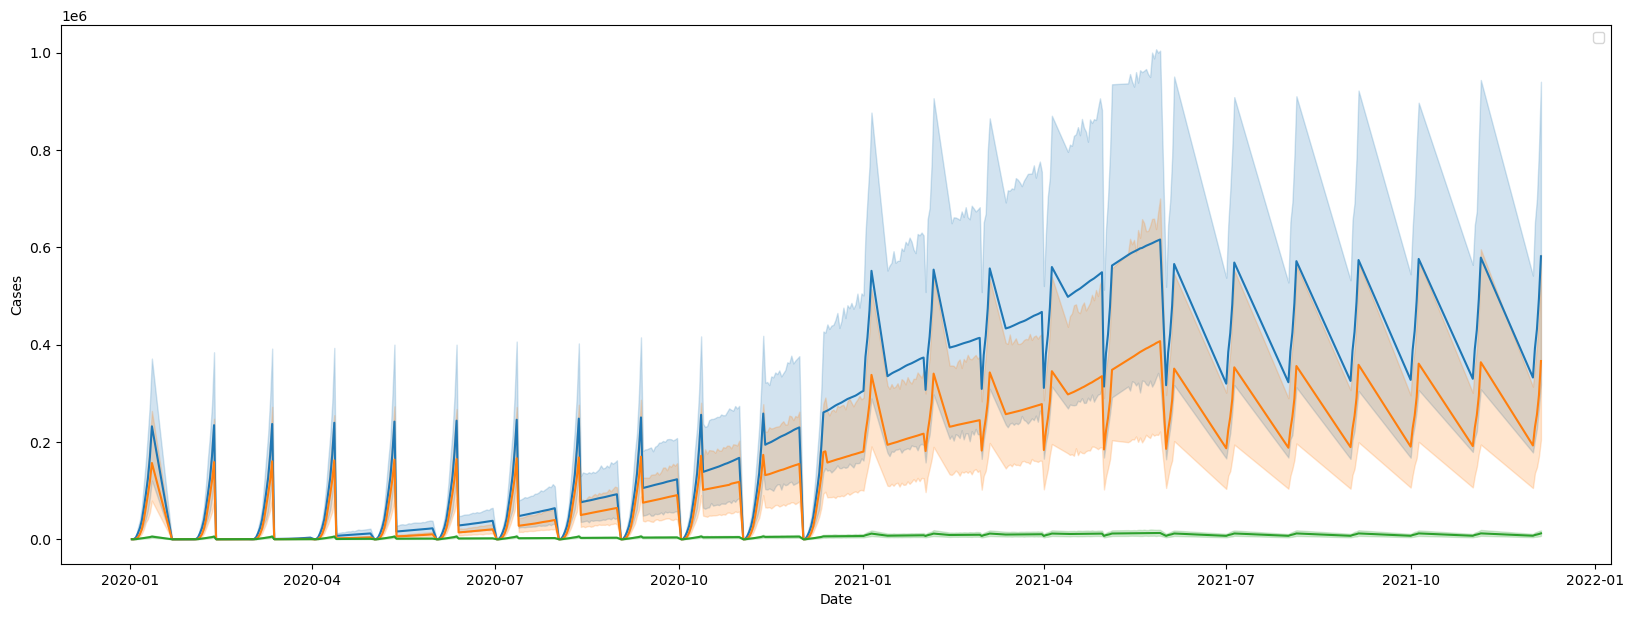

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
sns.lineplot(data=cc_rc_dc,x='Date',y='Cases')
sns.lineplot(data=cc_rc_dc,x='Date',y='recovered')
sns.lineplot(data=cc_rc_dc,x='Date',y='deaths')
plt.legend()
plt.show()

<Axes: xlabel='Country/Region', ylabel='Cases'>

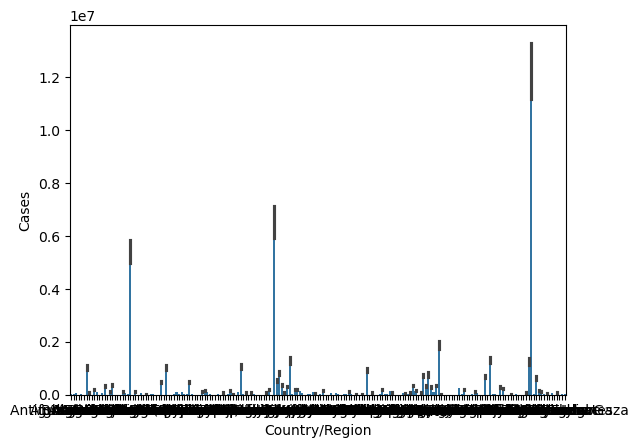

In [40]:
sns.barplot(data=cc_rc_dc,x='Country/Region',y='Cases')

In [41]:
Top10_region_cases=cc_rc_dc.groupby('Country/Region')['Cases'].sum().reset_index().sort_values(by='Cases',ascending=False).head(10)

<Axes: xlabel='Country/Region', ylabel='Cases'>

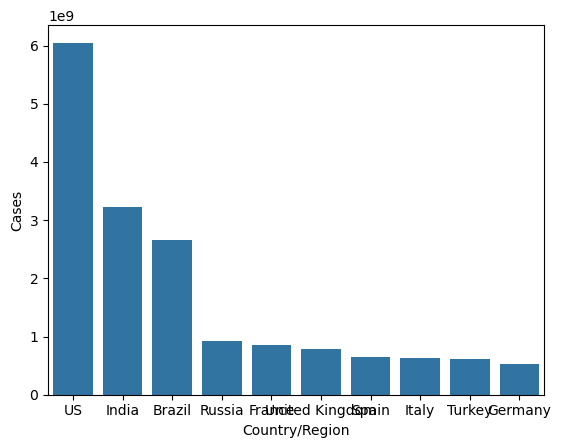

In [42]:
sns.barplot(data=Top10_region_cases,x='Country/Region',y='Cases')

In [43]:
cc_rc_dc.groupby('Date')['Cases'].sum().reset_index().sort_values(by='Cases',ascending=False).head(10)

,Date,Cases
458,2021-05-29,169951560
457,2021-05-28,169470725
456,2021-05-27,168970791
455,2021-05-26,168416423
454,2021-05-25,167848207
453,2021-05-24,167316362
452,2021-05-23,166862062
451,2021-05-22,166385987
450,2021-05-21,165808192
449,2021-05-20,165182316


In [44]:
cc_rc_dc.groupby('Date').agg({'Cases':'sum','recovered':'sum','deaths':'sum'}).reset_index()

,Date,Cases,recovered,deaths
0,2020-01-02,12038,287.0,259.0
1,2020-01-03,88394,42711.0,2996.0
2,2020-01-04,958602,191752.0,50526.0
3,2020-01-05,3368226,1029026.0,242572.0
4,2020-01-06,6284179,2641942.0,378115.0
...,...,...,...,...
489,2021-12-01,91689011,50074685.0,1969653.0
490,2021-12-02,108276434,59849414.0,2387299.0
491,2021-12-03,119062678,66541834.0,2641092.0
492,2021-12-04,136663253,76878905.0,2946232.0


In [45]:
cc_rc_dc['Date'].dt.month

0         1
1         1
2         1
3         1
4         1
         ..
136339    5
136340    5
136341    5
136342    5
136343    5
Name: Date, Length: 136344, dtype: int32

In [46]:
cc_rc_dc['Year_month']=cc_rc_dc['Date'].dt.to_period('M')

In [47]:
#month on month basis cases
MOM=cc_rc_dc.groupby('Year_month')['Cases'].sum().sort_index().reset_index()

In [48]:
MOM['Last_month_cases']=MOM['Cases'].shift(1)

In [49]:
MOM['MOM']=(MOM['Cases']-MOM['Last_month_cases'])/MOM['Last_month_cases']*100

In [50]:
MOM

,Year_month,Cases,Last_month_cases,MOM
0,2020-01,210010136,NaN,NaN
1,2020-02,213795867,2.100101e+08,1.802642
2,2020-03,222830262,2.137959e+08,4.225711
3,2020-04,264535012,2.228303e+08,18.715927
4,2020-05,319501969,2.645350e+08,20.778708
5,2020-06,385703356,3.195020e+08,20.720181
6,2020-07,515473465,3.857034e+08,33.645056
7,2020-08,668503200,5.154735e+08,29.687219
8,2020-09,797629615,6.685032e+08,19.315751
9,2020-10,1029929486,7.976296e+08,29.123777


In [51]:
cc_rc_dc_India=cc_rc_dc[cc_rc_dc['Country/Region']=='India']

In [52]:
MOM_India= cc_rc_dc_India.groupby('Year_month')['Cases'].sum().sort_index().reset_index()

In [53]:
MOM_India

,Year_month,Cases
0,2020-01,30485312
1,2020-02,30808267
2,2020-03,31147362
3,2020-04,31862823
4,2020-05,34235127
5,2020-06,40079302
6,2020-07,56486543
7,2020-08,90790793
8,2020-09,133899718
9,2020-10,180587333


In [54]:
cc_rc_dc_China=cc_rc_dc[cc_rc_dc['Country/Region']=='China']

In [55]:
MOM_China= cc_rc_dc_China.groupby('Year_month')['Cases'].sum().sort_index().reset_index()

In [56]:
MOM_China

,Year_month,Cases
0,2020-01,917838
1,2020-02,2146373
2,2020-03,2437129
3,2020-04,2400860
4,2020-05,2495134
5,2020-06,2423773
6,2020-07,2541121
7,2020-08,2611083
8,2020-09,2538770
9,2020-10,2645636


In [57]:
cc_rc_dc_Russia= cc_rc_dc[cc_rc_dc['Country/Region']=='Russia']

In [58]:
MOM_Russia = cc_rc_dc_Russia.groupby('Year_month')['Cases'].sum().sort_index().reset_index()

In [59]:
MOM_Russia

,Year_month,Cases
0,2020-01,8132327
1,2020-02,8220998
2,2020-03,8325835
3,2020-04,9442414
4,2020-05,14692720
5,2020-06,19147283
6,2020-07,23651202
7,2020-08,26828440
8,2020-09,28878924
9,2020-10,36674028
